# Fatigue, Form, and the Efficiency of Tennis Rankings
## Predicting ATP Match Outcomes (1991–2024) — Final Implementation

**Data & AI in Economics · TU Dortmund · Group D** — Divine Zacharias (lead), Franz Großmann


We test whether a match's winner can be predicted from **pre-match** information and whether a model can beat the **"higher-ranked player wins"** benchmark — an information-efficiency test analogous to market-efficiency tests in finance. Three method blocks feed that question:


## Part 0 — Setup & configuration
Run on Google Colab. The first cell installs DoWhy and clones Jeff Sackmann's `tennis_atp` dataset (CC BY-NC-SA, attribution required: https://github.com/JeffSackmann/tennis_atp). Everything else uses libraries pre-installed in Colab.

In [1]:
# --- install DoWhy (only extra dependency); clone the data ---
import sys, subprocess, os
subprocess.run([sys.executable, "-m", "pip", "-q", "install", "dowhy"], check=False)

if not os.path.isdir("tennis_atp"):
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/JeffSackmann/tennis_atp.git"], check=True)
print("data folder ready:", os.path.isdir("tennis_atp"))

data folder ready: True


In [2]:
# --- imports ---
import warnings; warnings.filterwarnings("ignore")
import glob, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, accuracy_score, log_loss,
                             roc_auc_score, roc_curve, adjusted_rand_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import binomtest
RNG = np.random.default_rng(42)
pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 110

# --- CONFIG: the three reviewer guardrails live here as explicit parameters ---
START_YEAR     = 1991            # detailed match stats reliable from 1991
TRAIN_END      = 2019            # (3) split boundary BEFORE the 2020-21 ranking freeze
COVID_WASHOUT  = {2020, 2021}    # (3) ATP froze/altered ranking points -> held out, reported apart
TEST_START     = 2022            # (3) primary test set = post-normalisation seasons

TREAT_PCTILE   = 0.75           # (2) "long match" = duration >= this percentile, WITHIN best_of
FATIGUE_WINDOW = 5              # (2) previous match must be within N days for fatigue to be plausible

K_ARCH         = 4              # (1) number of style archetypes used as a predictive feature
MIN_SEASON_MATCHES = 15        # min matches for a stable per-player-season style profile
print("config loaded")# --- imports ---
import warnings; warnings.filterwarnings("ignore")
import glob, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, accuracy_score, log_loss,
                             roc_auc_score, roc_curve, adjusted_rand_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import binomtest
RNG = np.random.default_rng(42)
pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 110

# --- CONFIG: the three reviewer guardrails live here as explicit parameters ---
START_YEAR     = 1991            # detailed match stats reliable from 1991
TRAIN_END      = 2019            # (3) split boundary BEFORE the 2020-21 ranking freeze
COVID_WASHOUT  = {2020, 2021}    # (3) ATP froze/altered ranking points -> held out, reported apart
TEST_START     = 2022            # (3) primary test set = post-normalisation seasons

TREAT_PCTILE   = 0.75           # (2) "long match" = duration >= this percentile, WITHIN best_of
FATIGUE_WINDOW = 5              # (2) previous match must be within N days for fatigue to be plausible

K_ARCH         = 4              # (1) number of style archetypes used as a predictive feature
MIN_SEASON_MATCHES = 15        # min matches for a stable per-player-season style profile
print("config loaded")

config loaded
config loaded


## Part 1 — Load & clean
We load **tour-level** singles matches only (`atp_matches_YYYY.csv`; excluding qualifying/challenger, futures, doubles files) from 1991. Cleaning targets the data-quality issues flagged in the proposal: impossible heights, impossible/absurd durations, and we build an **estimated within-tournament match date** from the round so that "rest days" and "previous match" respect the true playing order inside a tournament.

In [3]:
files = sorted(glob.glob("tennis_atp/atp_matches_[12]*.csv"))
files = [f for f in files if all(x not in f for x in ["qual_chall", "futures", "doubles"])]
df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
df = df[df.tourney_date // 10000 >= START_YEAR].copy()

df["year"] = df.tourney_date // 10000
df["date"] = pd.to_datetime(df.tourney_date, format="%Y%m%d")

# data-quality cleaning
for c in ["winner_ht", "loser_ht"]:
    df.loc[(df[c] < 150) | (df[c] > 220), c] = np.nan      # impossible heights (saw 3 cm)
df.loc[(df.minutes <= 0) | (df.minutes > 360), "minutes"] = np.nan  # impossible/absurd durations

# within-tournament ordering + estimated match date (rounds are ~1 day apart)
round_order = {"RR":0,"BR":0,"ER":0,"R128":1,"R64":2,"R32":3,"R16":4,"QF":5,"SF":6,"F":7}
day_off     = {"RR":0,"BR":0,"ER":0,"R128":0,"R64":1,"R32":2,"R16":3,"QF":4,"SF":5,"F":6}
df["rord"]  = df["round"].map(round_order).fillna(3).astype(int)
df["mdate"] = df["date"] + pd.to_timedelta(df["round"].map(day_off).fillna(2).astype(int), unit="D")

df = df.sort_values(["date","tourney_id","rord","match_num"]).reset_index(drop=True)
df["match_uid"] = np.arange(len(df))
print(f"matches: {len(df):,} | years {int(df.year.min())}-{int(df.year.max())} | "
      f"both ranks present: {int((df.winner_rank.notna()&df.loser_rank.notna()).sum()):,}")

matches: 112,706 | years 1991-2026 | both ranks present: 109,391


## Part 2 — Chronological feature engineering (leakage-safe)
The winner/loser encoding is a trap: any feature that peeks at the current row leaks the label. We therefore **reshape to one row per player per match** (`long`), sort each player's matches in time, and build every feature with a **`.shift(1)`** so it uses *strictly past* matches only. A built-in assertion re-derives one feature by hand and **fails loudly** if any look-ahead crept in.

Features (all trailing): recent form (last ≤10), surface-specific form (last ≤20 on that surface), rest days, previous-match duration, and career match count.

In [4]:
def _side(d, who):
    opp = "loser" if who == "winner" else "winner"
    sp  = "w_" if who == "winner" else "l_"          # own serve-stat prefix
    osp = "l_" if who == "winner" else "w_"          # opponent serve-stat prefix
    out = pd.DataFrame({
        "match_uid": d.match_uid, "mdate": d.mdate, "year": d.year,
        "tourney_id": d.tourney_id, "surface": d.surface, "best_of": d.best_of,
        "rord": d.rord, "minutes": d.minutes,
        "pid": d[f"{who}_id"], "oid": d[f"{opp}_id"],
        "rank": d[f"{who}_rank"], "opp_rank": d[f"{opp}_rank"],
        "rank_pts": d[f"{who}_rank_points"], "opp_rank_pts": d[f"{opp}_rank_points"],
        "age": d[f"{who}_age"], "ht": d[f"{who}_ht"],
        # own serve stats (for style profiles in Part 4)
        "ace": d[f"{sp}ace"], "df": d[f"{sp}df"], "svpt": d[f"{sp}svpt"],
        "firstIn": d[f"{sp}1stIn"], "firstWon": d[f"{sp}1stWon"], "secondWon": d[f"{sp}2ndWon"],
        "bpSaved": d[f"{sp}bpSaved"], "bpFaced": d[f"{sp}bpFaced"],
        # opponent serve stats (=> this player's RETURN context)
        "o_svpt": d[f"{osp}svpt"], "o_firstWon": d[f"{osp}1stWon"], "o_secondWon": d[f"{osp}2ndWon"],
    })
    out["won"] = 1 if who == "winner" else 0
    return out

long = pd.concat([_side(df, "winner"), _side(df, "loser")], ignore_index=True)
long = long.sort_values(["pid", "mdate", "match_uid"]).reset_index(drop=True)

g = long.groupby("pid", sort=False)
long["rest_days"]    = (long["mdate"] - g["mdate"].shift(1)).dt.days
long["prev_minutes"] = g["minutes"].shift(1)
long["prev_best_of"] = g["best_of"].shift(1)
long["career_n"]     = g.cumcount()                                  # # prior matches
long["form10"]       = (g["won"].apply(lambda s: s.shift(1).rolling(10, min_periods=3).mean())
                                  .reset_index(level=0, drop=True))   # trailing win rate

# surface-specific trailing form
long = long.sort_values(["pid", "surface", "mdate", "match_uid"])
long["surf_form"] = (long.groupby(["pid", "surface"], sort=False)["won"]
                         .apply(lambda s: s.shift(1).rolling(20, min_periods=3).mean())
                         .reset_index(level=[0, 1], drop=True))
long = long.sort_values(["pid", "mdate", "match_uid"]).reset_index(drop=True)

# ---- LEAKAGE ASSERTION: recompute form10 for one player by hand ----
_p   = long.pid.value_counts().index[3]
_sub = long[long.pid == _p].reset_index(drop=True)
_man = _sub["won"].shift(1).rolling(10, min_periods=3).mean()
assert np.allclose(_man.values, _sub["form10"].values, equal_nan=True), "LEAKAGE: form10 peeks ahead!"
print("leakage assertion PASSED — all trailing features use strictly past matches")
print(f"rest_days missing {long.rest_days.isna().mean():.1%} (first matches) | "
      f"form10 missing {long.form10.isna().mean():.1%}")

leakage assertion PASSED — all trailing features use strictly past matches
rest_days missing 1.6% (first matches) | form10 missing 4.0%


## Part 3 — Exploratory analysis & the ranking baseline
The **"higher-ranked player wins"** rule is the benchmark our model must beat. We compute its accuracy per era, show how it scales with the ranking gap, and quantify how common fatigue and current form are — both motivating the causal and feature work.

Ranking-baseline accuracy by era
  train  ≤2019: 0.6534  (n=92,110)
  covid 20-21: 0.6379  (n=4,123)
  test   ≥2022: 0.6402  (n=13,158)


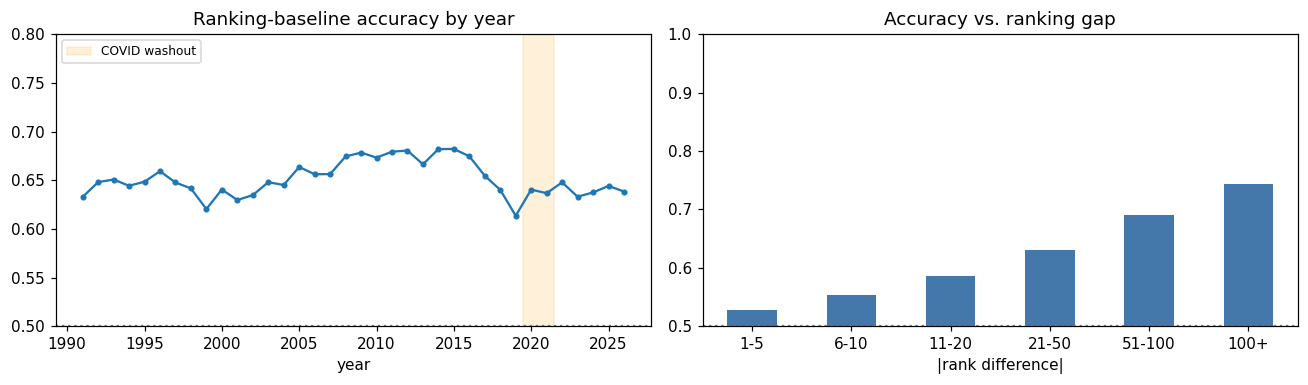

In [5]:
base = df[df.winner_rank.notna() & df.loser_rank.notna()].copy()
base["higher_ranked_won"] = (base.winner_rank < base.loser_rank).astype(int)  # lower number = better
acc_by_year = base.groupby("year")["higher_ranked_won"].mean()

print("Ranking-baseline accuracy by era")
for lab, yrs in [("train  ≤2019", base.year <= TRAIN_END),
                 ("covid 20-21", base.year.isin(COVID_WASHOUT)),
                 ("test   ≥2022", base.year >= TEST_START)]:
    print(f"  {lab}: {base.loc[yrs,'higher_ranked_won'].mean():.4f}  (n={int(yrs.sum()):,})")

# accuracy vs ranking gap
base["gap"] = (base.winner_rank - base.loser_rank).abs()
gb = pd.cut(base.gap, [0,5,10,20,50,100,10000],
            labels=["1-5","6-10","11-20","21-50","51-100","100+"])
acc_by_gap = base.groupby(gb, observed=True)["higher_ranked_won"].mean()

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].plot(acc_by_year.index, acc_by_year.values, marker="o", ms=3)
ax[0].axhspan(0,1, xmin=0, xmax=0); ax[0].axvspan(2019.5, 2021.5, color="orange", alpha=.15, label="COVID washout")
ax[0].axhline(0.5, ls=":", c="grey"); ax[0].set_ylim(.5,.8)
ax[0].set_title("Ranking-baseline accuracy by year"); ax[0].set_xlabel("year"); ax[0].legend(fontsize=8)
acc_by_gap.plot(kind="bar", ax=ax[1], color="#4477aa")
ax[1].axhline(0.5, ls=":", c="grey"); ax[1].set_ylim(.5,1.0)
ax[1].set_title("Accuracy vs. ranking gap"); ax[1].set_xlabel("|rank difference|"); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

In [6]:
# prevalence of fatigue & form signals (on the modelling-eligible rows)
elig = long[long["rank"].notna() & long.opp_rank.notna()]
print(f"share of matches where the player had a previous match within {FATIGUE_WINDOW} days: "
      f"{(elig.rest_days <= FATIGUE_WINDOW).mean():.1%}")
print(f"median rest days between matches: {elig.rest_days.median():.0f}")
print(f"matches with a usable recent-form value: {elig.form10.notna().mean():.1%}")

share of matches where the player had a previous match within 5 days: 57.1%
median rest days between matches: 3
matches with a usable recent-form value: 97.0%


## Part 4 — Unsupervised: playing-style archetypes  

**No temporal target leakage.** We build per-player **season** style profiles from serve/return rate stats, then:
* **fit** K-Means on **training-period seasons only** and **freeze** the centroids;
* assign every later season to those fixed centroids (no refitting on the future);
* the archetype used to predict a match in season *S* is the cluster of that player's **season-(S−1)** profile.

So a March-2015 match is described by the player's **2014** archetype — only past information. (A rolling-52-week profile as-of match date is a finer-grained alternative; the previous-season aggregate is exactly the trailing definition the reviewer suggested.)

`K_ARCH` is set to 4 for interpretable archetypes. We report the silhouette curve honestly: it peaks at the coarse **k=2** serve-vs-return split, so **k=4 is an interpretability choice** (cross-checked by the elbow and by agreement with hierarchical clustering), used downstream as a categorical feature.

In [7]:
# ---- per-player-season style profiles (serve + return rates) ----
ps = long.dropna(subset=["svpt", "o_svpt"]).copy()
ps = ps[(ps.svpt > 0) & (ps.o_svpt > 0)]
agg = ps.groupby(["pid", "year"]).agg(
    n=("svpt", "size"), ace=("ace","sum"), df=("df","sum"), svpt=("svpt","sum"),
    firstIn=("firstIn","sum"), firstWon=("firstWon","sum"), secondWon=("secondWon","sum"),
    bpSaved=("bpSaved","sum"), bpFaced=("bpFaced","sum"),
    o_svpt=("o_svpt","sum"), o_firstWon=("o_firstWon","sum"), o_secondWon=("o_secondWon","sum"),
).reset_index()
agg = agg[agg.n >= MIN_SEASON_MATCHES]

P = pd.DataFrame({"pid": agg.pid, "year": agg.year})
P["ace_rate"] = agg.ace / agg.svpt
P["df_rate"]  = agg.df  / agg.svpt
P["firstIn"]  = agg.firstIn / agg.svpt
P["firstWon"] = agg.firstWon / agg.firstIn
P["secondWon"]= agg.secondWon / (agg.svpt - agg.firstIn)
P["bpSaved"]  = agg.bpSaved / agg.bpFaced.replace(0, np.nan)
P["retWon"]   = (agg.o_svpt - agg.o_firstWon - agg.o_secondWon) / agg.o_svpt
FEATS = ["ace_rate","df_rate","firstIn","firstWon","secondWon","bpSaved","retWon"]
P = P.dropna(subset=FEATS).reset_index(drop=True)
print(f"player-season style profiles: {len(P):,}")

# ---- scale on TRAIN seasons, choose k via silhouette ----
Ptr = P[P.year <= TRAIN_END]
scaler = StandardScaler().fit(Ptr[FEATS])
Xtr = scaler.transform(Ptr[FEATS])
sil = {k: silhouette_score(Xtr, KMeans(k, n_init=10, random_state=0).fit_predict(Xtr))
       for k in range(2, 7)}
print("silhouette by k:", {k: round(v, 3) for k, v in sil.items()},
      "| silhouette-optimal k =", max(sil, key=sil.get), "| using K_ARCH =", K_ARCH)

player-season style profiles: 4,399
silhouette by k: {2: np.float64(0.221), 3: np.float64(0.19), 4: np.float64(0.174), 5: np.float64(0.161), 6: np.float64(0.153)} | silhouette-optimal k = 2 | using K_ARCH = 4


Archetype centroids (original units):


,size,ace_rate,df_rate,firstIn,firstWon,secondWon,bpSaved,retWon
0,1115,0.067,0.050,0.564,0.708,0.477,0.580,0.370
1,1537,0.070,0.033,0.602,0.718,0.521,0.622,0.379
2,1055,0.036,0.033,0.639,0.656,0.490,0.567,0.389
3,692,0.133,0.046,0.594,0.773,0.513,0.652,0.343


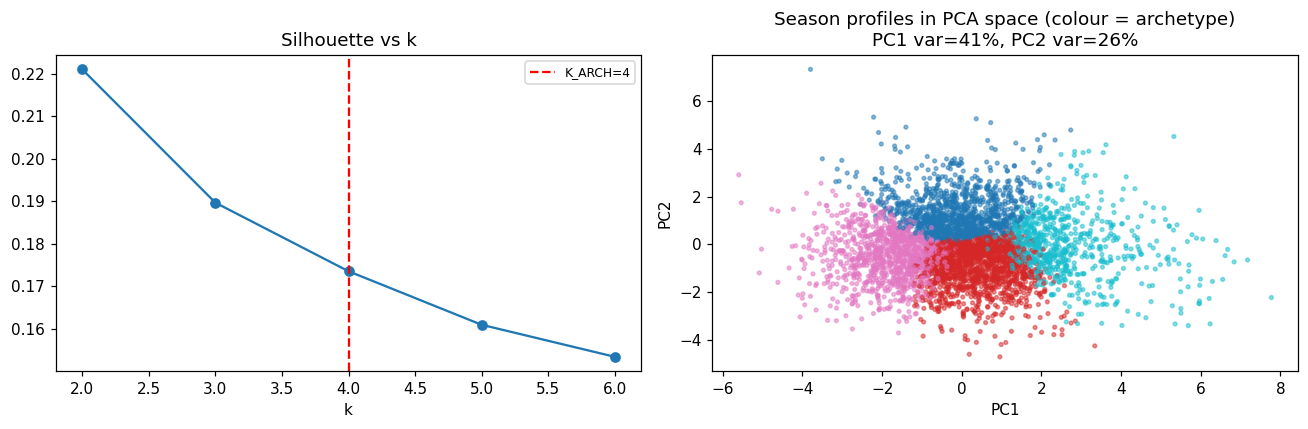

In [8]:
# ---- fit FROZEN K-Means on train seasons; assign all seasons ----
km = KMeans(K_ARCH, n_init=20, random_state=0).fit(Xtr)
P["arch"] = km.predict(scaler.transform(P[FEATS]))

# interpret centroids (original units)
cent = pd.DataFrame(scaler.inverse_transform(km.cluster_centers_), columns=FEATS)
cent.insert(0, "size", pd.Series(P.arch.value_counts().sort_index().values))
print("Archetype centroids (original units):"); display(cent.round(3))

# silhouette curve + PCA scatter
pca = PCA(2, random_state=0).fit(Xtr)
emb = pca.transform(scaler.transform(P[FEATS]))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(sil), list(sil.values()), marker="o")
ax[0].axvline(K_ARCH, ls="--", c="red", label=f"K_ARCH={K_ARCH}")
ax[0].set_title("Silhouette vs k"); ax[0].set_xlabel("k"); ax[0].legend(fontsize=8)
scsc = ax[1].scatter(emb[:,0], emb[:,1], c=P.arch, cmap="tab10", s=6, alpha=.5)
ax[1].set_title(f"Season profiles in PCA space (colour = archetype)\n"
                f"PC1 var={pca.explained_variance_ratio_[0]:.0%}, PC2 var={pca.explained_variance_ratio_[1]:.0%}")
ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2")
plt.tight_layout(); plt.show()

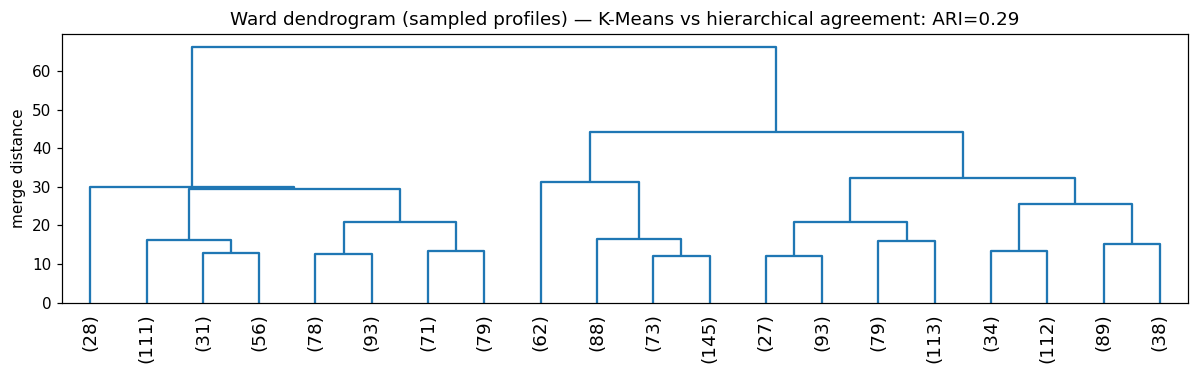

Adjusted Rand Index between K-Means and hierarchical (k=4) labels: 0.287


In [9]:
# ---- hierarchical clustering as robustness check (dendrogram + agreement) ----
samp = P.sample(min(1500, len(P)), random_state=0)
Z = linkage(scaler.transform(samp[FEATS]), method="ward")
hier_labels_full = AgglomerativeClustering(n_clusters=K_ARCH, linkage="ward").fit_predict(
    scaler.transform(P[FEATS]))
ari = adjusted_rand_score(P.arch, hier_labels_full)

plt.figure(figsize=(11, 3.5))
dendrogram(Z, truncate_mode="lastp", p=20, leaf_rotation=90, color_threshold=0)
plt.title(f"Ward dendrogram (sampled profiles) — K-Means vs hierarchical agreement: ARI={ari:.2f}")
plt.ylabel("merge distance"); plt.tight_layout(); plt.show()
print(f"Adjusted Rand Index between K-Means and hierarchical (k={K_ARCH}) labels: {ari:.3f}")

In [10]:
# ---- LEAKAGE-SAFE predictive feature: prior-season archetype ----
arch_feat = P[["pid", "year", "arch"]].copy()
arch_feat["year"] = arch_feat["year"] + 1                 # shift forward => "previous season" archetype
arch_feat = arch_feat.rename(columns={"arch": "arch_prev"})
print("prior-season archetype feature rows:", f"{len(arch_feat):,}",
      "\nexample — a player's 2014 profile becomes their archetype for 2015 matches.")

prior-season archetype feature rows: 4,399 
example — a player's 2014 profile becomes their archetype for 2015 matches.


## Part 5 — Causal: does fatigue lower next-match win probability?  *(proposal 7a)*

**Rigorous treatment.** Treatment `long_prev_match = 1` iff the player's **previous** match duration is **≥ the 75th percentile within its `best_of` format**, with the percentile estimated on **training data only** (no leakage, and conditioning on `best_of` avoids mechanically labelling every 5-setter "long"). *Structural alternative considered:* defining treatment as a 5-set vs straight-set previous match; we use the duration-percentile definition because it captures effort **within** a format and is continuous-data-driven. We additionally restrict the causal sample to cases where the previous match was within **`FATIGUE_WINDOW` days**, so fatigue is physiologically plausible, and still adjust for exact rest days.

**Identification.** Backdoor adjustment for common causes of *having had a long previous match* and *winning now*: own quality (log rank), opponent quality (log rank), surface, format, rest days, age, experience, and recent form. We estimate with **DoWhy** (propensity-score weighting) and validate with **placebo**, **random-common-cause**, and **subset** refuters, cross-checked by a hand-rolled IPW estimator with a bootstrap CI.

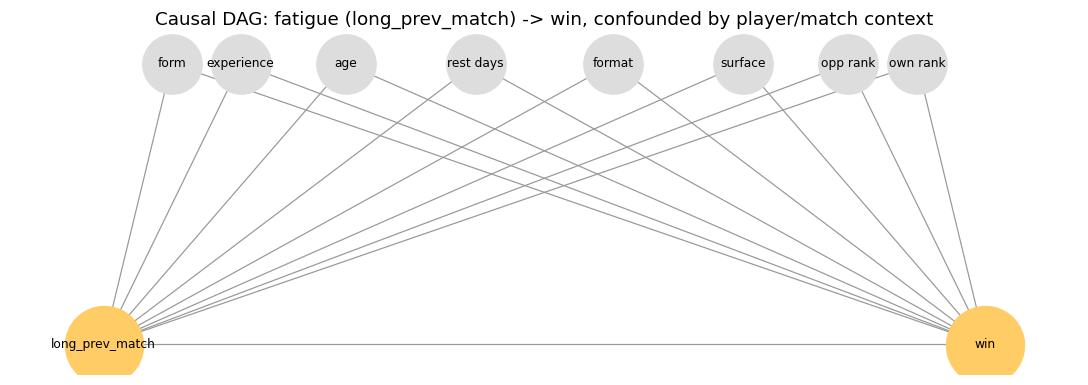

In [11]:
# DAG sketch (drawn with networkx; no graphviz needed)
import networkx as nx
G = nx.DiGraph()
conf_nodes = ["own rank","opp rank","surface","format","rest days","age","experience","form"]
for c in conf_nodes:
    G.add_edge(c, "long_prev_match"); G.add_edge(c, "win")
G.add_edge("long_prev_match", "win")
pos = {"long_prev_match": (-1, 0), "win": (1, 0)}
for i, c in enumerate(conf_nodes):
    pos[c] = (np.cos(np.pi*(i+1)/(len(conf_nodes)+1))*0.9, 1.4)
plt.figure(figsize=(10, 3.6))
nx.draw_networkx_nodes(G, pos, nodelist=conf_nodes, node_color="#dddddd", node_size=1500)
nx.draw_networkx_nodes(G, pos, nodelist=["long_prev_match","win"], node_color="#ffcc66", node_size=2600)
nx.draw_networkx_edges(G, pos, edge_color="#999999", arrowsize=10, width=.8)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title("Causal DAG: fatigue (long_prev_match) -> win, confounded by player/match context")
plt.axis("off"); plt.tight_layout(); plt.show()

In [12]:
# ---- build the causal sample with the rigorously-defined treatment ----
thr = (df[df.year <= TRAIN_END].groupby("best_of")["minutes"]
         .quantile(TREAT_PCTILE).to_dict())                       # train-only thresholds
print("long-match duration thresholds (train, "
      f"{int(TREAT_PCTILE*100)}th pct) by best_of: " + str({k: round(v) for k, v in thr.items()}))

c = long.copy()
c["prev_thr"]        = c["prev_best_of"].map(thr)
c["long_prev_match"] = (c["prev_minutes"] >= c["prev_thr"]).astype(float)
c.loc[c["prev_minutes"].isna(), "long_prev_match"] = np.nan
c["lrank"]  = np.log(c["rank"].clip(lower=1))
c["lorank"] = np.log(c["opp_rank"].clip(lower=1))

c = c[c.long_prev_match.notna() & c["rank"].notna() & c.opp_rank.notna()
      & c.rest_days.notna() & c.surface.notna() & c.age.notna()]
c = c[c.rest_days <= FATIGUE_WINDOW].copy()                       # fatigue plausible
c["form10"] = c.form10.fillna(0.5)
print(f"causal sample n = {len(c):,} | treated (long prev match) = {c.long_prev_match.mean():.1%}")
print(f"naive win rate  treated={c.loc[c.long_prev_match==1,'won'].mean():.3f}  "
      f"control={c.loc[c.long_prev_match==0,'won'].mean():.3f}  "
      f"(naive gap {100*(c.loc[c.long_prev_match==1,'won'].mean()-c.loc[c.long_prev_match==0,'won'].mean()):+.2f} pp)")

long-match duration thresholds (train, 75th pct) by best_of: {3: 114, 5: 175}
causal sample n = 113,798 | treated (long prev match) = 27.9%
naive win rate  treated=0.469  control=0.511  (naive gap -4.25 pp)


In [13]:
# ---- DoWhy: identify -> estimate (propensity weighting) -> refute ----
from dowhy import CausalModel
cc = pd.get_dummies(c, columns=["surface"], drop_first=True)
surf_cols = [k for k in cc.columns if k.startswith("surface_")]
conf = ["lrank","lorank","rest_days","age","career_n","best_of","form10"] + surf_cols
dat = cc[["long_prev_match","won"] + conf].astype(float).reset_index(drop=True)

model = CausalModel(data=dat, treatment="long_prev_match", outcome="won", common_causes=conf)
ident = model.identify_effect(proceed_when_unidentifiable=True)
est = model.estimate_effect(ident, method_name="backdoor.propensity_score_weighting",
                            target_units="ate", method_params={"weighting_scheme": "ips_weight"})
ate_dowhy = est.value
print(f"DoWhy IPW estimate (ATE): {100*ate_dowhy:+.2f} percentage points\n")

for name, kw in [("placebo (permute treatment)", dict(method_name="placebo_treatment_refuter",
                                                       placebo_type="permute", num_simulations=40)),
                 ("random common cause",         dict(method_name="random_common_cause",
                                                       num_simulations=20)),
                 ("subset (80%)",                dict(method_name="data_subset_refuter",
                                                       subset_fraction=0.8, num_simulations=20))]:
    r = model.refute_estimate(ident, est, **kw)
    pval = getattr(r, "refutation_result", {}) or {}
    print(f"  refuter [{name}]: new effect = {100*r.new_effect:+.2f} pp"
          + (f", p={pval.get('p_value')}" if isinstance(pval, dict) and 'p_value' in pval else ""))

DoWhy IPW estimate (ATE): -2.00 percentage points



             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.


  refuter [placebo (permute treatment)]: new effect = +2.38 pp, p=1.3759951804827347e-10


             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.


  refuter [random common cause]: new effect = -2.00 pp, p=nan


             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.


  refuter [subset (80%)]: new effect = -2.03 pp, p=0.3925593820030834


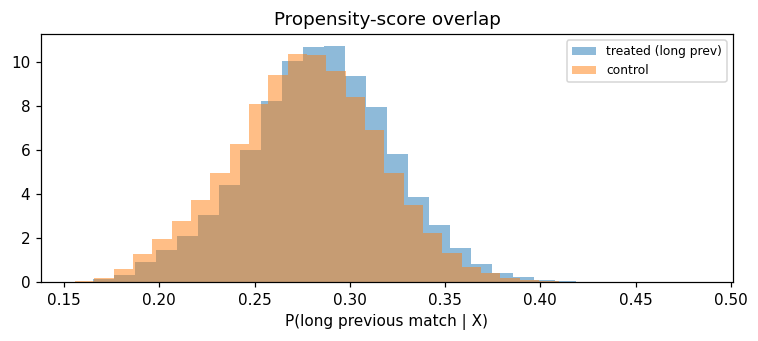

manual IPW ATE         : -2.20 pp   95% CI [-2.90, -1.53]
stratification ATE     : -2.36 pp
DoWhy IPW ATE (above)  : -2.00 pp


In [14]:
# ---- hand-rolled IPW + stratification cross-check with bootstrap CI ----
Xp = pd.get_dummies(c[["lrank","lorank","rest_days","age","career_n","best_of","surface"]],
                    columns=["surface"], drop_first=True).astype(float)
Xp["form10"] = c.form10.values
T = c.long_prev_match.values.astype(int); Y = c.won.values
sc = StandardScaler().fit(Xp); Xs = sc.transform(Xp)
e = np.clip(LogisticRegression(max_iter=2000).fit(Xs, T).predict_proba(Xs)[:,1], .02, .98)

w1, w0 = T/e, (1-T)/(1-e)
ate_ipw = (np.sum(w1*Y)/np.sum(w1)) - (np.sum(w0*Y)/np.sum(w0))
q = pd.qcut(e, 5, labels=False, duplicates="drop")
d, n = [], []
for s in np.unique(q):
    m = q == s
    if T[m].sum() > 5 and (1-T[m]).sum() > 5:
        d.append(Y[m][T[m]==1].mean() - Y[m][T[m]==0].mean()); n.append(m.sum())
ate_strat = np.average(d, weights=n)

bs = []
for _ in range(300):
    idx = RNG.integers(0, len(Y), len(Y))
    ei = np.clip(LogisticRegression(max_iter=400).fit(Xs[idx], T[idx]).predict_proba(Xs[idx])[:,1], .02, .98)
    w1i, w0i = T[idx]/ei, (1-T[idx])/(1-ei)
    bs.append((np.sum(w1i*Y[idx])/np.sum(w1i)) - (np.sum(w0i*Y[idx])/np.sum(w0i)))
lo, hi = np.percentile(bs, [2.5, 97.5])

# propensity overlap
plt.figure(figsize=(7, 3.2))
plt.hist(e[T==1], bins=30, alpha=.5, density=True, label="treated (long prev)")
plt.hist(e[T==0], bins=30, alpha=.5, density=True, label="control")
plt.title("Propensity-score overlap"); plt.xlabel("P(long previous match | X)"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"manual IPW ATE         : {100*ate_ipw:+.2f} pp   95% CI [{100*lo:+.2f}, {100*hi:+.2f}]")
print(f"stratification ATE     : {100*ate_strat:+.2f} pp")
print(f"DoWhy IPW ATE (above)  : {100*ate_dowhy:+.2f} pp")
ATE_PP = 100*ate_ipw   # carried into the synthesis